In [1]:
from relbench.datasets import get_dataset, get_dataset_names, register_dataset

In [90]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # Set timestamps or other relevant information if needed
    val_timestamp = pd.Timestamp("2024-01-23")
    test_timestamp = pd.Timestamp("2024-01-30")

    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/", "trans")   
        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "synTrans.csv")



        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['d_dat'])
        split_date = pd.to_datetime('2022-01-01')
        transactions_df = transactions_df[transactions_df['d_dat'] >= split_date]
        transactions_df = transactions_df.reset_index(drop=True)
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################

        # Handle duplicates in the articles table
        if articles_df.duplicated(subset=['articles_id']).any():
            print("Duplicates found in the 'articles_id' column. Removing duplicates...")
            articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')

        # Handle duplicates in the customers table
        if customers_df.duplicated(subset=['customers_id']).any():
            print("Duplicates found in the 'customers_id' column. Removing duplicates...")
            customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')

        # Handle duplicates in the branches table
        if branches_df.duplicated(subset=['BranchCode']).any():
            print("Duplicates found in the 'BranchCode' column. Removing duplicates...")
            branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')

        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        # Drop unnecessary columns
        transactions_df.drop(columns=["factor_id"], inplace=True)
        transactions_df.drop(columns=["date"], inplace=True)
        transactions_df.drop(columns=["art_name"], inplace=True)
        transactions_df.drop(columns=["price_item"], inplace=True)
        transactions_df.drop(columns=["BranchName"], inplace=True)
        transactions_df.drop(columns=["FoodTypeName"], inplace=True)
        transactions_df.drop(columns=["FoodType"], inplace=True)
        transactions_df.drop(columns=["Maliat"], inplace=True)       
        transactions_df.drop(columns=["Service"], inplace=True)            
        transactions_df.drop(columns=["group_id"], inplace=True)            
        # articles_df.drop(columns=["Item Barcode", "External Item Number"], inplace=True)

        transactions_df['Sales channel'] = pd.factorize(transactions_df['Sales channel'])[0]

        # Encoding Payment channel column
        # transactions_df['week'] = pd.factorize(transactions_df['week'])[0]


        # Replace any missing or invalid values
        # transactions_df["salesTime"] = transactions_df["salesTime"].replace(r"^\\N$", "00:00:00", regex=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Combine date and time into a single 'datetime' column
        # transactions_df['datetime'] = pd.to_datetime(transactions_df['d_dat'] + ' ' + transactions_df['salesTime'])
        # transactions_df.drop(columns=["d_dat"], inplace=True)        
        # Convert date column to pd.Timestamp
        # transactions_df["datetime"] = pd.to_datetime(transactions_df["datetime"])

        transactions_df["datetime"] = pd.to_datetime(
        transactions_df["d_dat"], format="%Y-%m-%d"
        )
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        # Convert other fields if necessary
        transactions_df['price_purchase'] = pd.to_numeric(transactions_df['price_purchase'], errors='coerce')
        transactions_df['takhfif'] = pd.to_numeric(transactions_df['takhfif'], errors='coerce')
        transactions_df['Quantity'] = pd.to_numeric(transactions_df['Quantity'], errors='coerce')

        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################

        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table (renamed from "branche" to "branches")
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [357]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # # Set timestamps or other relevant information if needed
    # val_timestamp = pd.Timestamp("2024-11-17")
    # test_timestamp = pd.Timestamp("2024-12-18")
    # Set timestamps or other relevant information if needed
    val_timestamp = pd.Timestamp("2025-01-3")
    test_timestamp = pd.Timestamp("2025-01-11")
    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/", "dorsa")   

        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "transaction_data.csv")


        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['Datetime'])
        transactions_df.drop(columns=["Datetime"], inplace=True)  
        # split_date = pd.to_datetime('2022-01-01')
        # transactions_df = transactions_df[transactions_df['d_dat'] >= split_date]
        transactions_df = transactions_df.reset_index(drop=True)
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################
        customers_df['customers_id'] = customers_df['Customer ID']
        customers_df.drop(columns=["Customer ID"], inplace=True)

        articles_df['articles_id'] = articles_df["Article ID"]
        articles_df.drop(columns=["Article ID"], inplace=True)

        transactions_df['articles_id'] = transactions_df["Article ID"]
        transactions_df.drop(columns=["Article ID"], inplace=True)

        transactions_df['customers_id'] = transactions_df['Customer ID']
        transactions_df.drop(columns=["Customer ID"], inplace=True)

        transactions_df['BranchCode'] = transactions_df['Branch ID']
        transactions_df.drop(columns=["Branch ID"], inplace=True)

        branches_df['BranchCode'] = branches_df['Branch ID']
        branches_df.drop(columns=["Branch ID"], inplace=True)        
        # Handle duplicates in the articles table
        if articles_df.duplicated(subset=['articles_id']).any():
            print("Duplicates found in the 'articles_id' column. Removing duplicates...")
            articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')

        # Handle duplicates in the customers table
        if customers_df.duplicated(subset=['customers_id']).any():
            print("Duplicates found in the 'customers_id' column. Removing duplicates...")
            customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')

        # Handle duplicates in the branches table
        if branches_df.duplicated(subset=['BranchCode']).any():
            print("Duplicates found in the 'BranchCode' column. Removing duplicates...")
            branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')

        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        # Drop unnecessary columns
        
        transactions_df.drop(columns=["Document Barcode"], inplace=True)
        transactions_df.drop(columns=["Net Sales"], inplace=True)
        # transactions_df.drop(columns=["art_name"], inplace=True)
        # transactions_df.drop(columns=["price_item"], inplace=True)
        # transactions_df.drop(columns=["BranchName"], inplace=True)
        # transactions_df.drop(columns=["FoodTypeName"], inplace=True)
        # transactions_df.drop(columns=["FoodType"], inplace=True)
        # transactions_df.drop(columns=["Maliat"], inplace=True)       
        # transactions_df.drop(columns=["Service"], inplace=True)            
        # transactions_df.drop(columns=["group_id"], inplace=True)            
        # articles_df.drop(columns=["Item Barcode", "External Item Number"], inplace=True)

        # transactions_df['Sales channel'] = pd.factorize(transactions_df['Sales channel'])[0]

        # Encoding Payment channel column
        # transactions_df['week'] = pd.factorize(transactions_df['week'])[0]


        # Replace any missing or invalid values
        # transactions_df["salesTime"] = transactions_df["salesTime"].replace(r"^\\N$", "00:00:00", regex=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Combine date and time into a single 'datetime' column
        # transactions_df['datetime'] = pd.to_datetime(transactions_df['d_dat'] + ' ' + transactions_df['salesTime'])
        # transactions_df.drop(columns=["d_dat"], inplace=True)        
        # Convert date column to pd.Timestamp
        # transactions_df["datetime"] = pd.to_datetime(transactions_df["datetime"])

        transactions_df["datetime"] = pd.to_datetime(
        transactions_df["d_dat"], format="%Y-%m-%d"
        )
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        # Convert other fields if necessary
        # transactions_df['price_purchase'] = pd.to_numeric(transactions_df['price_purchase'], errors='coerce')
        # transactions_df['takhfif'] = pd.to_numeric(transactions_df['takhfif'], errors='coerce')
        # transactions_df['Quantity'] = pd.to_numeric(transactions_df['Quantity'], errors='coerce')

        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################

        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table (renamed from "branche" to "branches")
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [3]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # Set timestamps or other relevant information if needed
    # val_timestamp = pd.Timestamp("2024-11-17")
    # test_timestamp = pd.Timestamp("2024-12-18")
    val_timestamp = pd.Timestamp("2025-01-3")
    test_timestamp = pd.Timestamp("2025-01-11")
    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/dorsa/", "new")   

        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "transaction_data.csv")

        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['Datetime'])
        transactions_df.drop(columns=["Datetime"], inplace=True)  
        transactions_df = transactions_df.reset_index(drop=True)
        
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################
        # customers_df['customers_id'] = customers_df['Customer ID']
        # customers_df.drop(columns=["Customer ID"], inplace=True)

        # articles_df['articles_id'] = articles_df["Article ID"]
        # articles_df.drop(columns=["Article ID"], inplace=True)

        # transactions_df['articles_id'] = transactions_df["Article ID"]
        # transactions_df.drop(columns=["Article ID"], inplace=True)

        # transactions_df['customers_id'] = transactions_df['Customer ID']
        # transactions_df.drop(columns=["Customer ID"], inplace=True)

        # transactions_df['BranchCode'] = transactions_df['Branch ID']
        # transactions_df.drop(columns=["Branch ID"], inplace=True)

        # branches_df['BranchCode'] = branches_df['Branch ID']
        # branches_df.drop(columns=["Branch ID"], inplace=True)        

        # Handle duplicates in the articles table
        articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')
        
        # Handle duplicates in the customers table
        customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')
        
        # Handle duplicates in the branches table
        branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')
        
        ################################################################################
        # Filter customers with 3 or more transactions
        ################################################################################
        customer_transaction_counts = transactions_df['customers_id'].value_counts()
        valid_customers = customer_transaction_counts[customer_transaction_counts >= 3].index
        transactions_df = transactions_df[transactions_df['customers_id'].isin(valid_customers)]
        customers_df = customers_df[customers_df['customers_id'].isin(valid_customers)]
        
        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        transactions_df.drop(columns=["Document Barcode", "Net Sales",'Net Sales Minus Sales Voucher','Tax','Small Change Discount','Base Total Price', 'Year', 'Month', 'Day', 'Allocated Credit', 'Sales Voucher', 'Gift Voucher', 'Cash Card', 'Special Discount', 'Promotion Discount'], inplace=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Convert date column to pd.Timestamp
        transactions_df["datetime"] = pd.to_datetime(transactions_df["d_dat"], format="%Y-%m-%d")
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        
        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################
        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [4]:
transactional_dataset = TransactionalDataset()
db = transactional_dataset.make_db()

In [5]:
table = db.table_dict["transactions"]

In [6]:
db.table_dict["transactions"].df.describe()

,BranchCode,Transaction Serial,customers_id,articles_id,Style Code,Quantity,Sale Total Price,Total Discounts,Discount Percentage,datetime
count,360698.000000,360698.000000,3.606980e+05,360698.000000,360698.00000,360698.000000,3.606980e+05,3.606980e+05,360698.000000,360698
mean,10414.970491,36659.250667,1.028951e+07,42093.038572,2997.25380,1.236741,6.745767e+07,1.948162e+07,3.623573,2022-12-16 23:26:04.274049024
min,10001.000000,100.000000,1.000000e+07,1048.000000,99.00000,1.000000,1.000000e+00,-1.485000e+08,-2284.620000,2021-03-21 11:15:15
25%,10131.000000,8634.000000,1.017943e+07,38036.000000,2374.00000,1.000000,1.246789e+07,2.000000e+00,0.000000,2021-12-22 11:26:21
50%,10317.000000,22164.000000,1.032058e+07,44168.000000,3037.00000,1.000000,3.005909e+07,4.220448e+06,0.000000,2022-10-25 17:04:12
75%,10642.000000,57178.000000,1.040394e+07,49766.000000,3670.00000,1.000000,5.742202e+07,1.730952e+07,0.000000,2024-01-18 19:47:57.500000
max,13827.000000,146172.000000,1.048279e+07,63063.000000,5367.00000,14390.000000,2.862386e+10,2.930959e+10,100.000000,2025-01-19 23:54:03
std,312.068203,37009.869494,1.333624e+05,11605.668984,932.19883,36.573872,2.430170e+08,9.498931e+07,12.731389,NaN


In [81]:
b = db.table_dict["article"]

In [82]:
b.df.describe()

,articles_id,Base Unit Price,Style Code,Collection Code,Idea Code,Initial Pattern Code,Year
count,7440.0,7.440000e+03,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000
mean,3719.5,4.235657e+07,502.110484,7.325134,0.012231,176.222849,1379.825403
std,2147.887334,5.906584e+07,300.053261,14.488141,0.152007,99.793045,165.905661
min,0.0,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1859.75,1.087200e+07,253.750000,0.000000,0.000000,78.000000,1398.000000
50%,3719.5,2.600000e+07,443.000000,0.000000,0.000000,198.000000,1400.000000
75%,5579.25,5.459023e+07,733.250000,0.000000,0.000000,277.000000,1401.000000
max,7439.0,2.419000e+09,1122.000000,57.000000,3.000000,277.000000,1403.000000


In [83]:
c = db.table_dict["customer"]

In [452]:
c.df.columns

Index(['Customer Category', 'customers_id', 'Customer Process', 'City'], dtype='object')

In [453]:
d = db.table_dict["branches"]

In [454]:
d.df.columns

Index(['BranchCode', 'Branch Name', 'City'], dtype='object')

In [100]:
table.df.iloc[table.df["datetime"].idxmax()]

Transaction Type                         فاکتور فروش
Transaction Serial                           24075.0
Time                                        23:54:03
Quantity                                           5
Base Total Price                                 0.0
Sale Total Price                                 0.0
Year                                          1403.0
Month                                           10.0
Day                                             30.0
Season                                        زمستان
Allocated Credit                                 0.0
Sales Voucher                                    0.0
Gift Voucher                                     0.0
Cash Card                                        0.0
Special Discount                                 0.0
Promotion Discount                               0.0
Small Change Discount                            0.0
Tax                                              0.0
Total Discounts                               

In [101]:
table.df.iloc[table.df["datetime"].idxmin()]

Transaction Type                         فاکتور فروش
Transaction Serial                            6445.0
Time                                        11:15:15
Quantity                                          10
Base Total Price                                10.0
Sale Total Price                                10.0
Year                                          1400.0
Month                                            1.0
Day                                              1.0
Season                                          بهار
Allocated Credit                                 1.0
Sales Voucher                                    0.0
Gift Voucher                                     0.0
Cash Card                                        0.0
Special Discount                                 0.0
Promotion Discount                               0.0
Small Change Discount                            0.0
Tax                                              1.0
Total Discounts                               

In [7]:
register_dataset("Dorsa-aras14", TransactionalDataset)
get_dataset_names()

['rel-amazon',
 'rel-avito',
 'rel-event',
 'rel-f1',
 'rel-hm',
 'rel-stack',
 'rel-trial',
 'Dorsa-aras14']

In [8]:
hyper_dataset = get_dataset("Dorsa-aras14")
hyper_dataset

TransactionalDataset()

In [9]:
hyper_dataset.val_timestamp, hyper_dataset.test_timestamp

(Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-11 00:00:00'))

In [10]:
import relbench

relbench.__version__

'1.1.0'

In [11]:
import duckdb
import pandas as pd
from relbench.tasks import get_task, get_task_names, register_task
from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.metrics import (
    accuracy,
    average_precision,
    f1,
    link_prediction_map,
    link_prediction_precision,
    link_prediction_recall,
    mae,
    r2,
    rmse,
    roc_auc,
)
from metrics import link_prediction_top
class UserItemPurchaseTask(RecommendationTask):
    r"""Predict the list of articles each customer will purchase in the next seven
    days."""

    task_type = TaskType.LINK_PREDICTION
    src_entity_col = "customer_id"
    src_entity_table = "customer"
    dst_entity_col = "article_id"
    dst_entity_table = "article"
    time_col = "timestamp"
    timedelta = pd.Timedelta(days=7)
    metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map, link_prediction_top]
    eval_k = 12

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                t.timestamp,
                transactions.customer_id,
                LIST(DISTINCT transactions.article_id) AS article_id
            FROM
                timestamp_df t
            LEFT JOIN
                transactions
            ON
                transactions.t_dat > t.timestamp AND
                transactions.t_dat <= t.timestamp + INTERVAL '{self.timedelta} days'
            GROUP BY
                t.timestamp,
                transactions.customer_id
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={
                self.src_entity_col: self.src_entity_table,
                self.dst_entity_col: self.dst_entity_table,
            },
            pkey_col=None,
            time_col=self.time_col,
        )

# Task 1: Predict articles each customer will purchase in the next 7 days
# class CustomerArticlePurchaseTask(RecommendationTask):
#     r"""Predict the list of articles each customer will purchase in the next seven days."""
    
#     task_type = TaskType.LINK_PREDICTION
#     src_entity_col = "customers_id"
#     src_entity_table = "customer"
#     dst_entity_col = "articles_id"
#     dst_entity_table = "article"
#     time_col = "timestamp"
#     timedelta = pd.Timedelta(days=7)
#     metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map, link_prediction_top]
#     eval_k = 4

#     def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
#         transactions = db.table_dict["transactions"].df
#         timestamp_df = pd.DataFrame({"timestamp": timestamps})

#         df = duckdb.sql(
#             f"""
#             SELECT
#                 t.timestamp,
#                 transactions.customers_id,
#                 LIST(DISTINCT transactions.articles_id) AS articles_id
#             FROM
#                 timestamp_df t
#             LEFT JOIN
#                 transactions
#             ON
#                 transactions.datetime > t.timestamp AND
#                 transactions.datetime <= t.timestamp + INTERVAL '{self.timedelta.days} days'
#             GROUP BY
#                 t.timestamp,
#                 transactions.customers_id
#             """
#         ).df()

#         return Table(
#             df=df,
#             fkey_col_to_pkey_table={
#                 self.src_entity_col: self.src_entity_table,
#                 self.dst_entity_col: self.dst_entity_table,
#             },
#             pkey_col=None,
#             time_col=self.time_col,
#         )


# Task 2: Predict customer churn (no purchases in the next week)
class CustomerChurnTask(EntityTask):
    r"""Predict the churn for a customer (no transactions)  in the next week."""

    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = "customers_id"
    entity_table = "customer"
    time_col = "timestamp"
    target_col = "churn"
    timedelta = pd.Timedelta(days=7)
    timedelta1 = pd.Timedelta(days=7)
    metrics = [average_precision, accuracy, f1, roc_auc]
    # metrics = [average_precision, accuracy, f1]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                timestamp,
                customers_id,
                CAST(
                    NOT EXISTS (
                        SELECT 1
                        FROM transactions
                        WHERE
                            transactions.customers_id = customer.customers_id AND
                            transactions.datetime > timestamp AND
                            transactions.datetime <= timestamp + INTERVAL '{self.timedelta}'
                    ) AS INTEGER
                ) AS churn
            FROM
                timestamp_df,
                customer
            WHERE
                EXISTS (
                    SELECT 1
                    FROM transactions
                    WHERE
                        transactions.customers_id = customer.customers_id AND
                        transactions.datetime > timestamp - INTERVAL '{self.timedelta1}' AND
                        transactions.datetime <= timestamp
                )
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        ) 
class CustomerChurnTask1(EntityTask):
    r"""Predict the churn for a customer (no transactions) in the next week."""

    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = "customers_id"
    entity_table = "customer"
    time_col = "timestamp"
    target_col = "churn"
    timedelta = pd.Timedelta(days=7)  # Next 7 days
    timedelta1 = pd.Timedelta(days=7)  # Last 180 days (for activity check)
    metrics = [average_precision, accuracy, f1, roc_auc]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                timestamp,
                customers_id,
                CAST(
                    EXISTS (
                        SELECT 1
                        FROM transactions
                        WHERE
                            transactions.customers_id = customer.customers_id AND
                            transactions.datetime > timestamp AND
                            transactions.datetime <= timestamp + INTERVAL '{self.timedelta}'
                    ) AS INTEGER
                ) AS churn
            FROM
                timestamp_df,
                customer
            WHERE
                EXISTS (
                    SELECT 1
                    FROM transactions
                    WHERE
                        transactions.customers_id = customer.customers_id AND
                        transactions.datetime > timestamp - INTERVAL '{self.timedelta1}' AND
                        transactions.datetime <= timestamp
                )
                """
                ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )
# Task 3: Predict article sales in the next 7 days
class ArticleSalesTask(EntityTask):
    r"""Predict the total sales for an article (sum of `price_purchase`) in the next 7 days."""
    
    task_type = TaskType.REGRESSION
    entity_col = "articles_id"
    entity_table = "article"
    time_col = "datetime"
    target_col = "sales"
    timedelta = pd.Timedelta(days=7)
    metrics = [r2, mae, rmse]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        transactions = db.table_dict["transactions"].df
        articles = db.table_dict["article"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                t.timestamp,
                a.articles_id,
                COALESCE(SUM(transactions.price_purchase), 0) AS sales
            FROM
                timestamp_df t,
                article a
            LEFT JOIN
                transactions
            ON
                transactions.articles_id = a.articles_id AND
                transactions.datetime > t.timestamp AND
                transactions.datetime <= t.timestamp + INTERVAL '{self.timedelta.days} days'
            GROUP BY
                t.timestamp,
                a.articles_id
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )



In [12]:
aras_churn_task = CustomerChurnTask1(hyper_dataset, cache_dir="D:/Dani/relbench/cache/burger_ara34s3ی3245516644434433433356rf3d3s3df2")
aras_churn_task

CustomerChurnTask1(dataset=TransactionalDataset())

In [13]:
register_task("Dorsa-aras14", "aras_churn_task", CustomerChurnTask1)
get_task_names("Dorsa-aras14")

['aras_churn_task']

In [14]:
import numpy as np

from torch.nn import BCEWithLogitsLoss, L1Loss
from relbench.datasets import get_dataset
from relbench.tasks import get_task

dataset = get_dataset("Dorsa-aras14")
task = get_task("Dorsa-aras14", "aras_churn_task")


train_table = task.get_table("train")
val_table = task.get_table("val")
test_table = task.get_table("test")

out_channels = 1
loss_fn = BCEWithLogitsLoss()
tune_metric = "roc_auc"
higher_is_better = True

Making task table for train split from scratch...
(You can also use `get_task(..., download=True)` for tasks prepared by the RelBench team.)
Making Database object from scratch...
(You can also use `get_dataset(..., download=True)` for datasets prepared by the RelBench team.)
Done in 3.00 seconds.
Caching Database object to C:\Users\KN2C\AppData\Local\relbench\relbench\Cache/Dorsa-aras14/db...
Done in 0.40 seconds.
Loading Database object from C:\Users\KN2C\AppData\Local\relbench\relbench\Cache/Dorsa-aras14/db...
Done in 0.34 seconds.
Done in 5.42 seconds.
Making task table for val split from scratch...
(You can also use `get_task(..., download=True)` for tasks prepared by the RelBench team.)
Done in 0.03 seconds.
Making task table for test split from scratch...
(You can also use `get_task(..., download=True)` for tasks prepared by the RelBench team.)
Loading Database object from C:\Users\KN2C\AppData\Local\relbench\relbench\Cache/Dorsa-aras14/db...
Done in 0.12 seconds.
Done in 0.16 s

In [15]:
train_table

Table(df=
        timestamp  customers_id  churn
0      2021-09-24         54854      0
1      2021-09-17         53754      0
2      2021-09-17         54085      0
3      2021-09-10         53926      1
4      2021-09-10         54772      0
...           ...           ...    ...
188762 2024-09-20          1531      0
188763 2024-09-20          1842      0
188764 2024-09-13           553      0
188765 2024-09-13          1094      0
188766 2024-09-13          1630      1

[188767 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [16]:
val_table

Table(df=
     timestamp  customers_id  churn
0   2025-01-03          1950      0
1   2025-01-03          2528      0
2   2025-01-03          2747      0
3   2025-01-03          2841      0
4   2025-01-03          2855      0
..         ...           ...    ...
668 2025-01-03         44588      1
669 2025-01-03         47632      0
670 2025-01-03         50683      0
671 2025-01-03         52535      0
672 2025-01-03         53848      0

[673 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [17]:
test_table

Table(df=
     timestamp  customers_id
0   2025-01-11           578
1   2025-01-11           962
2   2025-01-11          2821
3   2025-01-11          3366
4   2025-01-11          6941
..         ...           ...
841 2025-01-11         49085
842 2025-01-11         51854
843 2025-01-11         52186
844 2025-01-11         54793
845 2025-01-11         54942

[846 rows x 2 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [18]:
test_data1 = task.get_table("test", mask_input_cols=False)
test_data1

Table(df=
     timestamp  customers_id  churn
0   2025-01-11           578      0
1   2025-01-11           962      0
2   2025-01-11          2821      0
3   2025-01-11          3366      0
4   2025-01-11          6941      0
..         ...           ...    ...
841 2025-01-11         49085      1
842 2025-01-11         51854      0
843 2025-01-11         52186      0
844 2025-01-11         54793      0
845 2025-01-11         54942      0

[846 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [19]:
tes1 = test_data1.df

In [20]:
value_counts = tes1['churn'].value_counts()

# Display the result
print(value_counts)

churn
0    719
1    127
Name: count, dtype: int64


## Feature extraction

In [21]:
import os
import math
import numpy as np
from tqdm import tqdm

import torch
import torch_geometric
import torch_frame

# Some book keeping
from torch_geometric.seed import seed_everything

seed_everything(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # check that it's cuda if you want it to run in reasonable time!
root_dir = "./data_ARAS"

c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [22]:
from relbench.modeling.utils import get_stype_proposal

db = dataset.get_db()
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

{'article': {'articles_id': <stype.numerical: 'numerical'>,
  'Article Description': <stype.text_embedded: 'text_embedded'>,
  'Base Unit Price': <stype.numerical: 'numerical'>,
  'Style Code': <stype.numerical: 'numerical'>,
  'Style Description': <stype.text_embedded: 'text_embedded'>,
  'Collection Code': <stype.numerical: 'numerical'>,
  'Collection Name': <stype.text_embedded: 'text_embedded'>,
  'Idea Code': <stype.numerical: 'numerical'>,
  'Idea Description': <stype.text_embedded: 'text_embedded'>,
  'Initial Pattern Code': <stype.numerical: 'numerical'>,
  'Initial Pattern Description': <stype.text_embedded: 'text_embedded'>,
  'Product Category': <stype.categorical: 'categorical'>,
  'Product Group': <stype.text_embedded: 'text_embedded'>,
  'Product Subgroup': <stype.text_embedded: 'text_embedded'>,
  'Product Type': <stype.text_embedded: 'text_embedded'>,
  'Material Category': <stype.text_embedded: 'text_embedded'>,
  'Material Type': <stype.text_embedded: 'text_embedded'>

In [23]:
# from relbench.modeling.schema import Stype
from torch_frame import stype
# Modify specific column stype manually
col_to_stype_dict['article']['Style Code'] = stype.categorical  
col_to_stype_dict['article']['Collection Code'] = stype.categorical  
col_to_stype_dict['article']['Idea Code'] = stype.categorical  
col_to_stype_dict['article']['Initial Pattern Code'] = stype.categorical  
 
# col_to_stype_dict['transactions']['Year'] = stype.categorical 
# col_to_stype_dict['transactions']['Month'] = stype.categorical 

# Now you can use col_to_stype_dict in your modeling pipeline
print(col_to_stype_dict)

{'article': {'articles_id': <stype.numerical: 'numerical'>, 'Article Description': <stype.text_embedded: 'text_embedded'>, 'Base Unit Price': <stype.numerical: 'numerical'>, 'Style Code': <stype.categorical: 'categorical'>, 'Style Description': <stype.text_embedded: 'text_embedded'>, 'Collection Code': <stype.categorical: 'categorical'>, 'Collection Name': <stype.text_embedded: 'text_embedded'>, 'Idea Code': <stype.categorical: 'categorical'>, 'Idea Description': <stype.text_embedded: 'text_embedded'>, 'Initial Pattern Code': <stype.categorical: 'categorical'>, 'Initial Pattern Description': <stype.text_embedded: 'text_embedded'>, 'Product Category': <stype.categorical: 'categorical'>, 'Product Group': <stype.text_embedded: 'text_embedded'>, 'Product Subgroup': <stype.text_embedded: 'text_embedded'>, 'Product Type': <stype.text_embedded: 'text_embedded'>, 'Material Category': <stype.text_embedded: 'text_embedded'>, 'Material Type': <stype.text_embedded: 'text_embedded'>, 'Processing': 

In [480]:
from typing import List, Optional
from sentence_transformers import SentenceTransformer
from torch import Tensor
import torch

class HuggingFaceTextEmbedding:
    def __init__(self, model_name: str = "sentence-transformers/all-mpnet-base-v2", 
                 device: Optional[str] = None):
        """
        Initialize the sentence transformer model from Hugging Face.
        :param model_name: The Hugging Face model name for sentence embeddings.
        :param device: The device to use ('cpu' or 'cuda').
        """
        self.model = SentenceTransformer(model_name, device=device)

    def __call__(self, sentences: List[str]) -> Tensor:
        """
        Encode sentences using the Hugging Face sentence-transformer model.
        :param sentences: A list of sentences to encode.
        :return: A PyTorch tensor of embeddings.
        """
        embeddings = self.model.encode(sentences, convert_to_tensor=True)
        return embeddings


In [481]:
from torch_frame.config.text_embedder import TextEmbedderConfig
from relbench.modeling.graph import make_pkey_fkey_graph

# Initialize the text embedder with a Hugging Face model
text_embedder_cfg = TextEmbedderConfig(
    text_embedder=HuggingFaceTextEmbedding(
        model_name="sentence-transformers/all-mpnet-base-v2", device=device
    ), 
    batch_size=64
)

# Generate a graph-based dataset with embeddings
data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict=col_to_stype_dict,  # specified column types
    text_embedder_cfg=text_embedder_cfg,  # using Hugging Face text embeddings
    cache_dir=os.path.join(
        root_dir, f"rel-aras_churn_materialized_cache24"
    ),  # store materialized graph for convenience
)


c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Embedding raw data in mini-batch: 100%|██████████| 753/753 [00:59<00:00, 12.71it/s]
c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\torch_frame\data\stats.py:177: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  ser = pd.to_datetime(ser, format=time_format)
c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\torch_frame\data\mapper.py:290: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`

In [24]:
from typing import List, Optional
from sentence_transformers import SentenceTransformer
from torch import Tensor
import torch

class BertPersianTextEmbedding:
    def __init__(self, device: Optional[torch.device] = None):
        # Replace the model with a Persian BERT model
        self.model = SentenceTransformer("HooshvareLab/bert-fa-zwnj-base",  # Example Persian BERT model
            device=device,
        )

    def __call__(self, sentences: List[str]) -> Tensor:
        # Encode the sentences using the Persian BERT model and return as a tensor
        return torch.from_numpy(self.model.encode(sentences))


In [25]:
from torch_frame.config.text_embedder import TextEmbedderConfig
from relbench.modeling.graph import make_pkey_fkey_graph

text_embedder_cfg = TextEmbedderConfig(
    text_embedder=BertPersianTextEmbedding(device=device), batch_size=64
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict=col_to_stype_dict,  # speficied column types
    text_embedder_cfg=text_embedder_cfg,  # our chosen text encoder
    cache_dir=os.path.join(
        root_dir, f"rel-aras_churn_materialized_cache34"
    ),  # store materialized graph for convenience
)

No sentence-transformers model found with name HooshvareLab/bert-fa-zwnj-base. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Embedding raw data in mini-batch:   0%|          | 0/286 [00:00<?, ?it/s]c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: User

In [26]:
data

HeteroData(
  article={ tf=TensorFrame([18258, 28]) },
  branches={ tf=TensorFrame([75, 2]) },
  customer={ tf=TensorFrame([54955, 3]) },
  transactions={
    tf=TensorFrame([357020, 10]),
    time=[357020],
  },
  (transactions, f2p_articles_id, article)={ edge_index=[2, 357020] },
  (article, rev_f2p_articles_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_customers_id, customer)={ edge_index=[2, 357020] },
  (customer, rev_f2p_customers_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_BranchCode, branches)={ edge_index=[2, 357020] },
  (branches, rev_f2p_BranchCode, transactions)={ edge_index=[2, 357020] }
)

## GNN Implementation

In [27]:
import argparse
import copy
import json
import os
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn.functional as F
# from model import Model
# from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from tqdm import tqdm

from relbench.base import Dataset, RecommendationTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph
from relbench.modeling.loader import SparseTensor
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

In [28]:
from relbench.modeling.graph import get_node_train_table_input, make_pkey_fkey_graph
from torch_geometric.loader import NeighborLoader

loader_dict = {}


for split, table in [
    ("train", train_table),
    ("val", val_table),
    ("test", test_table),
]:
    table_input = get_node_train_table_input(
        table=table,
        task=task,
    )
    entity_table = table_input.nodes[0]
    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=[
            256 for i in range(4)
        ],  # we sample subgraphs of depth 2, 128 neighbors per node.
        time_attr="time",
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=512,
        temporal_strategy="uniform",
        shuffle=split == "train",
        num_workers=0,
        persistent_workers=False,
    )

In [36]:
from relbench.modeling.graph import get_node_train_table_input, make_pkey_fkey_graph
from torch_geometric.loader import NeighborLoader

loader_dict = {}


for split, table in [
    ("train", train_table),
    ("val", val_table),
    ("test", test_table),
]:
    table_input = get_node_train_table_input(
        table=table,
        task=task,
    )
    entity_table = table_input.nodes[0]
    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=[
            256 for i in range(3)
        ],  # we sample subgraphs of depth 2, 128 neighbors per node.
        time_attr="time",
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=512,
        temporal_strategy="uniform",
        shuffle=split == "train",
        num_workers=0,
        persistent_workers=False,
    )

In [37]:
from torch.nn import BCEWithLogitsLoss
import copy
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder


class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = True,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])


model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)


# if you try out different RelBench tasks you will need to change these
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10

In [38]:
def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    for batch in tqdm(loader_dict["train"]):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(
            batch,
            task.entity_table,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred

        loss = loss_fn(pred.float(), batch[entity_table].y.float())
        loss.backward()
        optimizer.step()

        loss_accum += loss.detach().item() * pred.size(0)
        count_accum += pred.size(0)

    return loss_accum / count_accum


@torch.no_grad()
def test(loader: NeighborLoader) -> np.ndarray:
    model.eval()

    pred_list = []
    for batch in loader:
        batch = batch.to(device)
        pred = model(
            batch,
            task.entity_table,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        pred_list.append(pred.detach().cpu())
    return torch.cat(pred_list, dim=0).numpy()

In [39]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

  0%|          | 0/369 [00:01<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.40 GiB. GPU 

In [131]:
model_save_path = "Dorsa_model1.pth"
torch.save(state_dict, model_save_path)

In [34]:
test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

Best test metrics: {'average_precision': np.float64(0.9837159759619983), 'accuracy': 0.9423314568172456, 'f1': np.float64(0.9700936354034392), 'roc_auc': np.float64(0.8070413296874958)}


In [169]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 565/565 [01:05<00:00,  8.65it/s]


Epoch: 01, Train loss: 0.2414975541133717, Val metrics: {'average_precision': np.float64(0.14849607996615885), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6176207193007593)}


100%|██████████| 565/565 [01:04<00:00,  8.74it/s]


Epoch: 02, Train loss: 0.2369921408765474, Val metrics: {'average_precision': np.float64(0.16528940295876007), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6314538854659215)}


100%|██████████| 565/565 [01:06<00:00,  8.52it/s]


...

Epoch: 08, Train loss: 0.2325167836109616, Val metrics: {'average_precision': np.float64(0.17409258792295015), 'accuracy': 0.9232192414431082, 'f1': np.float64(0.023529411764705882), 'roc_auc': np.float64(0.661448631609113)}


100%|██████████| 565/565 [01:05<00:00,  8.59it/s]


Epoch: 09, Train loss: 0.23241595943550375, Val metrics: {'average_precision': np.float64(0.16633807134244313), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6603142761618188)}


100%|██████████| 565/565 [01:06<00:00,  8.55it/s]


Epoch: 10, Train loss: 0.2317596764391489, Val metrics: {'average_precision': np.float64(0.17277765111191923), 'accuracy': 0.9259944495837188, 'f1': np.float64(0.09090909090909091), 'roc_auc': np.float64(0.6634546496632756)}
Best Val metrics: {'average_precision': np.float64(0.17286922620349432), 'accuracy': 0.9259944495837188, 'f1': np.float64(0.09090909090909091), 'roc_auc': np.float64(0.6634665902469313)}
Best test metrics: {'average_precision': np.float64(0.23289829896104242), 'accuracy': 0.8960546282245827, 'f1': np.float64(0.028368794326241134), 'roc_auc': np.float64(0.6494248966297274)}


In [225]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 2387/2387 [03:56<00:00, 10.10it/s]


Epoch: 01, Train loss: 0.20502651639105604, Val metrics: {'average_precision': np.float64(0.9697697494588908), 'accuracy': 0.940374526098112, 'f1': np.float64(0.9691689273479733), 'roc_auc': np.float64(0.6942309989945782)}


100%|██████████| 2387/2387 [03:55<00:00, 10.12it/s]


Epoch: 02, Train loss: 0.2015492363208246, Val metrics: {'average_precision': np.float64(0.9707073929208436), 'accuracy': 0.9407574771186765, 'f1': np.float64(0.9693802822476891), 'roc_auc': np.float64(0.7010806150941283)}


100%|██████████| 2387/2387 [03:56<00:00, 10.11it/s]


...

Epoch: 08, Train loss: 0.1981104319960383, Val metrics: {'average_precision': np.float64(0.971665820186683), 'accuracy': 0.9418297399762571, 'f1': np.float64(0.9700175670607741), 'roc_auc': np.float64(0.7075944816477183)}


100%|██████████| 2387/2387 [03:57<00:00, 10.04it/s]


Epoch: 09, Train loss: 0.19770088957627185, Val metrics: {'average_precision': np.float64(0.9715346637783392), 'accuracy': 0.9408340673227894, 'f1': np.float64(0.9694331783559205), 'roc_auc': np.float64(0.7066477583360669)}


100%|██████████| 2387/2387 [03:50<00:00, 10.37it/s]


Epoch: 10, Train loss: 0.19737171452135396, Val metrics: {'average_precision': np.float64(0.9710037673855457), 'accuracy': 0.9414084938536361, 'f1': np.float64(0.9697616506581288), 'roc_auc': np.float64(0.7010153826870098)}
Best Val metrics: {'average_precision': np.float64(0.9716659723560541), 'accuracy': 0.94190633018037, 'f1': np.float64(0.9700558615108269), 'roc_auc': np.float64(0.707597228556113)}
Best test metrics: {'average_precision': np.float64(0.970642274989393), 'accuracy': 0.9393212974754663, 'f1': np.float64(0.9686762829189064), 'roc_auc': np.float64(0.7157368202273662)}


In [269]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 500/500 [00:36<00:00, 13.57it/s]


Epoch: 01, Train loss: 0.29958606309361135, Val metrics: {'average_precision': np.float64(0.22104015663763307), 'accuracy': 0.8907849829351536, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6629379775102586)}


100%|██████████| 500/500 [00:35<00:00, 14.01it/s]


Epoch: 02, Train loss: 0.2932900631907203, Val metrics: {'average_precision': np.float64(0.22824467981622337), 'accuracy': 0.8907849829351536, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.665783910313088)}


100%|██████████| 500/500 [00:35<00:00, 14.03it/s]


...

Epoch: 08, Train loss: 0.2872027850937158, Val metrics: {'average_precision': np.float64(0.2446151009365661), 'accuracy': 0.8913100551325808, 'f1': np.float64(0.018957345971563982), 'roc_auc': np.float64(0.6766710025164931)}


100%|██████████| 500/500 [00:36<00:00, 13.84it/s]


Epoch: 09, Train loss: 0.28652190019257084, Val metrics: {'average_precision': np.float64(0.2382493425586153), 'accuracy': 0.8918351273300079, 'f1': np.float64(0.05504587155963303), 'roc_auc': np.float64(0.6740942891473396)}


100%|██████████| 500/500 [00:36<00:00, 13.87it/s]


Epoch: 10, Train loss: 0.28644649993908905, Val metrics: {'average_precision': np.float64(0.24623385693518696), 'accuracy': 0.8915725912312943, 'f1': np.float64(0.03278688524590164), 'roc_auc': np.float64(0.6741056247024417)}
Best Val metrics: {'average_precision': np.float64(0.23494560654649294), 'accuracy': 0.8902599107377265, 'f1': np.float64(0.045662100456621), 'roc_auc': np.float64(0.6773504273504274)}
Best test metrics: {'average_precision': np.float64(0.26280427440467735), 'accuracy': 0.8964688482159364, 'f1': np.float64(0.05405405405405406), 'roc_auc': np.float64(0.7147669117368952)}


In [555]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 312/312 [00:37<00:00,  8.42it/s]


Epoch: 01, Train loss: 0.3036382453270213, Val metrics: {'average_precision': np.float64(0.08149909583754936), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.382574963304676)}


100%|██████████| 312/312 [00:36<00:00,  8.55it/s]


Epoch: 02, Train loss: 0.29769873404821234, Val metrics: {'average_precision': np.float64(0.07927084788972695), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.37240511637659884)}


100%|██████████| 312/312 [00:36<00:00,  8.49it/s]


...

Epoch: 18, Train loss: 0.2815974957005092, Val metrics: {'average_precision': np.float64(0.07236593788583265), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.16333333333333333), 'roc_auc': np.float64(0.3112112951701964)}


100%|██████████| 312/312 [00:36<00:00,  8.46it/s]


Epoch: 19, Train loss: 0.28002526003469314, Val metrics: {'average_precision': np.float64(0.07483377593858881), 'accuracy': 0.10554561717352415, 'f1': np.float64(0.16666666666666666), 'roc_auc': np.float64(0.331795624519466)}


100%|██████████| 312/312 [00:36<00:00,  8.57it/s]


Epoch: 20, Train loss: 0.27847757654976885, Val metrics: {'average_precision': np.float64(0.0781954544439005), 'accuracy': 0.1001788908765653, 'f1': np.float64(0.171334431630972), 'roc_auc': np.float64(0.364122457538268)}
Best Val metrics: {'average_precision': np.float64(0.08149909583754936), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.382574963304676)}
Best test metrics: {'average_precision': np.float64(0.11981170288209966), 'accuracy': 0.14697802197802198, 'f1': np.float64(0.2562874251497006), 'roc_auc': np.float64(0.38755700031604134)}


In [170]:
test_pred = test(loader_dict["test"])

In [565]:
test_pred

array([2.2340145, 2.42365  , 2.3910878, 1.9651055, 2.635047 , 2.8125134,
       2.9141939, 2.2264369, 2.0779622, 2.3920996, 3.0969882, 2.4129744,
       3.0757098, 2.864708 , 2.5034294, 2.7289915, 2.6368017, 2.8812795,
       3.0616727, 3.026916 , 2.7588956, 3.1603408, 3.1004765, 3.018543 ,
       2.749207 , 2.0653594, 2.4637835, 3.0846555, 2.8144748, 2.2830656,
       2.3707862, 3.0710647, 2.431739 , 2.2137074, 1.8520021, 2.9022338,
       3.0094109, 1.9472306, 3.1234567, 3.0915687, 2.7333903, 2.2532468,
       3.1200771, 2.7500458, 2.7889016, 2.7099855, 2.807791 , 2.4613554,
       2.1795695, 2.4637082, 1.8362317, 2.2145002, 2.526186 , 2.8383348,
       2.7034883, 3.0142655, 2.7882974, 2.767608 , 2.2250628, 2.792282 ,
       2.7570925, 2.2517154, 2.635968 , 2.029555 , 2.903744 , 2.6759653,
       2.949788 , 2.7997477, 2.4565923, 2.020189 , 2.8271596, 2.4267097,
       2.492117 , 2.819358 , 2.5993326, 2.1765358, 1.9197769, 2.307284 ,
       2.3475156, 2.4267442, 2.7634962, 2.0826788, 

In [556]:
customer_ids = test_table.df["customers_id"].values  # Extract the customer_id column
predicted_labels = test_pred  # This contains the model's predicted labels

# Now zip customer_ids with the predictions
results = list(zip(customer_ids, predicted_labels))

# If you'd like to show or process the results, you can format them as a dataframe
results_df = pd.DataFrame(results, columns=["customers_id", "predicted_churn"])

# You can now inspect the predictions
print(results_df)

     customers_id  predicted_churn
0            1555         2.234015
1            2084         2.423650
2            2314         2.391088
3            2619         1.965106
4            2638         2.635047
..            ...              ...
723         44669         1.965225
724         46246         2.547095
725         46603         2.807388
726         47306         2.673507
727         47596         2.087492

[728 rows x 2 columns]


In [175]:
index_map_dict1 = db.reindex_pkeys_and_fkeys()
print(index_map_dict1)

{'article': articles_id
54821.0       0
53612.0       1
59459.0       2
54126.0       3
44301.0       4
           ... 
17315.0    7567
23028.0    7568
46775.0    7569
39866.0    7570
42931.0    7571
Name: index, Length: 7572, dtype: Int64, 'customer': customers_id
10121860.0         0
10447769.0         1
10469286.0         2
10075749.0         3
10432889.0         4
               ...  
10475955.0    149147
10465306.0    149148
10461949.0    149149
10477874.0    149150
10440367.0    149151
Name: index, Length: 149152, dtype: Int64, 'branches': BranchCode
10284.0     0
10124.0     1
10706.0     2
11008.0     3
10002.0     4
10100.0     5
10131.0     6
10562.0     7
11086.0     8
10593.0     9
10168.0    10
10267.0    11
10887.0    12
10008.0    13
10006.0    14
10003.0    15
10099.0    16
10656.0    17
10672.0    18
10536.0    19
10642.0    20
10594.0    21
10001.0    22
10748.0    23
10010.0    24
10113.0    25
10595.0    26
10732.0    27
11155.0    28
10803.0    29
10643.0    30
107

In [557]:
reverse_mapping = {v: k for k, v in index_map_dict1['customer'].items()}

# Map back to original customers_id
results_df['mapped_customers_id'] = results_df['customers_id'].map(reverse_mapping)

In [558]:
# Add label column based on threshold
results_df["label"] = (results_df["predicted_churn"] >= 0.5).astype(int)


In [559]:
test_data1 = task.get_table("test", mask_input_cols=False)
test1 = test_data1.df

In [560]:
reverse_mapping = {v: k for k, v in index_map_dict1['customer'].items()}

# Map back to original customers_id
test1['mapped_customers_id'] = test1['customers_id'].map(reverse_mapping)

In [561]:
test1

,timestamp,customers_id,churn,mapped_customers_id
0,2025-01-11,1555,0,10421084.0
1,2025-01-11,2084,0,10392031.0
2,2025-01-11,2314,0,10435708.0
3,2025-01-11,2619,0,10479974.0
4,2025-01-11,2638,0,10074995.0
...,...,...,...,...
723,2025-01-11,44669,1,10356557.0
724,2025-01-11,46246,0,10367110.0
725,2025-01-11,46603,0,10418557.0
726,2025-01-11,47306,0,10408668.0


In [564]:
results_df

,customers_id,predicted_churn,mapped_customers_id,label
0,1555,2.234015,10421084.0,1
1,2084,2.423650,10392031.0,1
2,2314,2.391088,10435708.0,1
3,2619,1.965106,10479974.0,1
4,2638,2.635047,10074995.0,1
...,...,...,...,...
723,44669,1.965225,10356557.0,1
724,46246,2.547095,10367110.0,1
725,46603,2.807388,10418557.0,1
726,47306,2.673507,10408668.0,1


In [337]:
results_df.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\result_dorsa4.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_16676\3450000447.py:1: SyntaxWarning: invalid escape sequence '\D'
  results_df.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\result_dorsa4.csv', index=False)


In [319]:
test1.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\test_dorsa4.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_16676\653013400.py:1: SyntaxWarning: invalid escape sequence '\D'
  test1.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\test_dorsa4.csv', index=False)


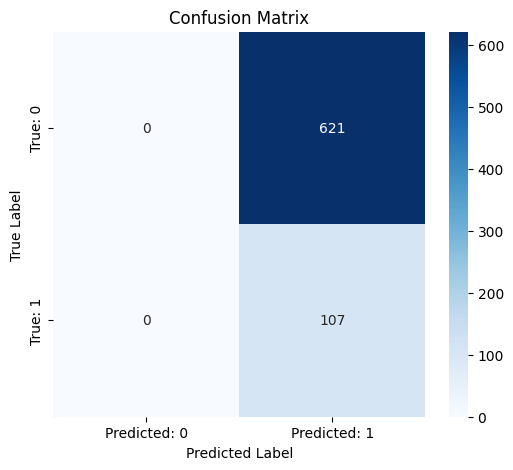

Confusion Matrix:
[[  0 621]
 [  0 107]]
ROC AUC Score: 0.5000


In [563]:
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

df_merge = pd.merge(results_df, test1, on="mapped_customers_id", how="inner")
y_pred = df_merge['label']
y_true = df_merge['churn']
# Step 1: Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Step 2: Calculate the ROC AUC score
# For ROC AUC, we need predicted probabilities (not just labels).
# So, assuming you have probability scores, here we will simulate a model 
# using predicted labels (0 or 1) as scores for simplicity.

# If you have probabilities, you would use them like this:
# roc_auc = roc_auc_score(y_true, y_pred_probabilities)

# Here we're using the predicted label itself as the score (0 or 1)
roc_auc = roc_auc_score(y_true, y_pred)

# Step 3: Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Predicted: 0", "Predicted: 1"], 
            yticklabels=["True: 0", "True: 1"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Print the confusion matrix and ROC AUC score
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC AUC Score: {roc_auc:.4f}")

# GNNExplainer

In [33]:
from torch_geometric.explain import GNNExplainer
import torch
import torch.nn.functional as F
from torch_geometric.loader import NeighborLoader
from tqdm import tqdm


In [35]:
explainer = GNNExplainer(model)

In [ ]:
# Print keys for all node types in the batch
for node_type in sample_batch.keys:
    print(node_type, sample_batch[node_type])


ValueError: Node type 'tf' does not have a feature matrix 'x'

In [55]:
import torch
from captum.attr import IntegratedGradients
from torch_geometric.data import Data
from torch_geometric.explain import CaptumExplainer

# Assuming model is already trained, and you have the validation data available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to prepare node features and edge index for explainer
def prepare_input_for_explainer(batch):
    # Assuming that the batch is a PyG Data object and 'x' holds the node features
    node_features = batch.x.to(device)  # Move node features to device
    edge_index = batch.edge_index.to(device)  # Edge indices to device

    return node_features, edge_index

# Initialize model and CaptumExplainer
model.eval()  # Set model to evaluation mode
ig = IntegratedGradients(model)  # Initialize Integrated Gradients method

# Prepare the batch for explanation (take the validation batch for example)
batch = next(iter(loader_dict["val"]))  # Get one batch from the validation set
batch = batch.to(device)  # Move the batch to device

node_features, edge_index = prepare_input_for_explainer(batch)

# Forward pass to get the prediction
target = model(batch, task.entity_table)  # Model output
target = target.view(-1) if target.size(1) == 1 else target  # Flatten if necessary

# Choose a target index for explanation, let's say the first node in the batch
index = 0

# Initialize CaptumExplainer
captum_explainer = CaptumExplainer('IntegratedGradients')

# Compute attributions for the chosen target node
attributions, delta = captum_explainer.forward(
    model=model,
    x=node_features,
    edge_index=edge_index,
    target=target,
    index=index,
)

# Print out the attributions and delta (convergence information)
print("Attributions: ", attributions)
print("Delta: ", delta)


AttributeError: 'HeteroData' has no attribute 'x'

In [45]:
!pip install captum


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.8 MB/s eta 0:00:00


In [63]:
import torch
from captum.attr import IntegratedGradients
from torch_geometric.explain import CaptumExplainer

# Assuming `batch` is the HeteroData object passed from your loader
# Move to device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch = batch.to(device)  # Move batch to device

# Step 1: Extract node features for the 'transactions' node type
# Extract the features (assuming 'tf' is the key holding the features)
node_features = batch.transactions.tf.to(device)  # Node features for transactions

# Step 2: Extract edge indices for the 'transactions' node type
edge_index_trans_to_article = batch['transactions', 'f2p_articles_id', 'article'].edge_index.to(device)
edge_index_trans_to_customer = batch['transactions', 'f2p_customers_id', 'customer'].edge_index.to(device)
edge_index_trans_to_branches = batch['transactions', 'f2p_BranchCode', 'branches'].edge_index.to(device)

# Now you have node features for transactions and edge indices connecting transactions to articles, customers, and branches

# Example of selecting a target for attribution: Let's say we want to explain the prediction for the first 'transaction'
target = model(batch, task.entity_table)  # Get the model's output (prediction for each node)
target = target.view(-1) if target.size(1) == 1 else target  # Flatten if needed

# Initialize IntegratedGradients
ig = IntegratedGradients(model)

# For example, let's explain the prediction for the first 'transaction' (index 0)
index = 0

# Step 3: Use CaptumExplainer to compute attributions
captum_explainer = CaptumExplainer('IntegratedGradients')

# Compute the attributions for the first 'transaction'
attributions, delta = captum_explainer.forward(
    model=model,
    x=node_features,
    edge_index=edge_index_trans_to_article,  # Use appropriate edge index
    target=target,
    index=index,
)

# Print out the attributions and convergence delta
print("Attributions: ", attributions)
print("Delta: ", delta)


AttributeError: 'HeteroData' has no attribute 'transactions'

In [65]:
data['transactions'].tf

TensorFrame(
  num_cols=19,
  num_rows=283921,
  categorical (4): ['Month', 'Season', 'Transaction Type', 'Year'],
  numerical (13): ['Allocated Credit', 'Base Total Price', 'Cash Card', 'Day', 'Discount Percentage', 'Gift Voucher', 'Promotion Discount', 'Quantity', 'Sale Total Price', 'Sales Voucher', 'Special Discount', 'Total Discounts', 'Transaction Serial'],
  timestamp (2): ['Time', 'datetime'],
  has_target=False,
  device='cpu',
)

In [68]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

# Step 1: Define a simple GCN model (for demonstration)
class GCN(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, out_channels)

    def forward(self, data):
        # Forward function expects a Data object
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Step 2: Create a Data object (with x, edge_index, and y attributes)
dataset = Data(
    x=torch.rand(100, 28),  # 100 nodes, 28 features each
    edge_index=torch.randint(0, 100, (2, 200)),  # 200 edges
    y=torch.randint(0, 2, (100,))  # Binary labels for nodes
)  # Replace with your actual dataset loading code

# Step 3: Initialize the model and move it to the appropriate device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(in_channels=28, out_channels=2)  # Assuming 28 features per node, and 2 output classes
model.to(device)

# Step 4: Train the model (simplified training loop for demonstration)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    loss_accum = count_accum = 0
    optimizer.zero_grad()
    # Pass the Data object (not just the features)
    output = model(dataset.to(device))  # Pass dataset as Data object
    loss = loss_fn(output, dataset.y.to(device))
    loss.backward()
    optimizer.step()

    loss_accum += loss.item() * dataset.num_nodes
    count_accum += dataset.num_nodes

    return loss_accum / count_accum

# Training for a few epochs
for epoch in range(10):  # Adjust the number of epochs
    train_loss = train()
    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")

# Step 5: Explain the prediction using Captum (Integrated Gradients)
# Let's assume we want to explain the prediction for the first node in the dataset

# Prepare the Integrated Gradients
ig = IntegratedGradients(model)

# Choose the node you want to explain (for example, the first node)
node_index = 0  # Node index to explain

# Extract the feature matrix of the node type (assuming 'x' holds features)
input_features = dataset.x.to(device)  # Features of all nodes
target = dataset.y[node_index].to(device)  # Target label for the node

# Perform Integrated Gradients Attribution
attributions, delta = ig.attribute(input_features, target=target.item(), return_convergence_delta=True)

# Step 6: Visualize the attribution scores
attributions = attributions.detach().cpu().numpy()

# Plot the attribution for the node's features
plt.bar(range(len(attributions)), attributions[0])  # Assuming the first node
plt.xlabel('Feature Index')
plt.ylabel('Attribution Score')
plt.title(f'Attribution for Node {node_index}')
plt.show()

# Optionally, print the convergence delta (how well the method converged)
print("Convergence delta:", delta)


Epoch 1, Loss: 0.9130
Epoch 2, Loss: 0.7806
Epoch 3, Loss: 0.7010
Epoch 4, Loss: 0.6814
Epoch 5, Loss: 0.7112
Epoch 6, Loss: 0.7264
Epoch 7, Loss: 0.7189
Epoch 8, Loss: 0.7032
Epoch 9, Loss: 0.6888
Epoch 10, Loss: 0.6808


AttributeError: 'Tensor' object has no attribute 'x'

In [67]:
dataset.x

tensor([[0.3938, 0.0631, 0.5625,  ..., 0.3148, 0.3267, 0.3069],
        [0.2439, 0.5797, 0.5403,  ..., 0.8680, 0.8365, 0.3956],
        [0.7591, 0.6706, 0.6112,  ..., 0.7125, 0.8362, 0.8504],
        ...,
        [0.9171, 0.2762, 0.1820,  ..., 0.4018, 0.3371, 0.0824],
        [0.7816, 0.4303, 0.4045,  ..., 0.7534, 0.2394, 0.0380],
        [0.5042, 0.3512, 0.5019,  ..., 0.0884, 0.5829, 0.7648]])

In [75]:
from torch_geometric.data import HeteroData
from torch_geometric.explain import Explainer, CaptumExplainer

import torch
from torch_geometric.data import HeteroData

# Create a sample heterogeneous graph
data = HeteroData()

# Node types and features
data['author'].x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float)  # 2 authors, each with 2 features
data['paper'].x = torch.tensor([[5, 6], [7, 8]], dtype=torch.float)   # 2 papers, each with 2 features
data['institution'].x = torch.tensor([[9, 10]], dtype=torch.float)    # 1 institution, with 2 features

# Edge types
data['author', 'writes', 'paper'].edge_index = torch.tensor([[0, 1], [0, 1]], dtype=torch.long)  # author 0 writes paper 0, and author 1 writes paper 1
data['author', 'affiliated', 'institution'].edge_index = torch.tensor([[0, 1], [0, 0]], dtype=torch.long)  # author 0 and 1 are affiliated with institution 0

# Optional: Add target labels for each node
data['author'].y = torch.tensor([0, 1], dtype=torch.long)  # 2 authors with class labels 0 and 1
data['paper'].y = torch.tensor([1, 0], dtype=torch.long)   # 2 papers with class labels 1 and 0

# Print to see the data
print(data)


explainer = Explainer(
    model,  # It is assumed that model outputs a single tensor.
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config = dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='probs',  # Model returns probabilities.
    ),
)

# Generate batch-wise heterogeneous explanations for
# the nodes at index `1` and `3`:
hetero_explanation = explainer(
    data.x_dict,
    data.edge_index_dict,
    index=torch.tensor([1, 3]),
)
print(hetero_explanation.edge_mask_dict)
print(hetero_explanation.node_mask_dict)

HeteroData(
  author={
    x=[2, 2],
    y=[2],
  },
  paper={
    x=[2, 2],
    y=[2],
  },
  institution={ x=[1, 2] },
  (author, writes, paper)={ edge_index=[2, 2] },
  (author, affiliated, institution)={ edge_index=[2, 2] }
)


TypeError: GCN.forward() takes 2 positional arguments but 3 were given